# Lab: The Networking Toolkit — Observing the Stack Live
**Course:** Introduction to Networking  
**Topic:** Tools — ping, traceroute, ss, dig, tcpdump, Wireshark, pyshark  
**Format:** Guided Lab Notebook

---

## Overview

Every networking concept covered in lecture exists as observable, live state on your machine right now. This lab is about learning to *see* it.

The central idea: **make one HTTP request to a website and observe the same event from five different tool perspectives simultaneously** — ICMP, routing, TCP sockets, DNS, and raw packets. Each tool is a window into a different layer of the stack.

| Tool | Layer | What it shows |
|------|-------|---------------|
| `ping` | Network (L3) | ICMP RTT, TTL, reachability |
| `traceroute` | Network (L3) | Per-hop path, latency |
| `ss` | Transport (L4) | Live TCP socket state, cwnd, RTT |
| `dig` | Application (L7) | DNS queries and records |
| `tcpdump` | All layers | Raw packet capture |
| `pyshark` | All layers | Programmatic pcap analysis |

> **Note:** This lab assumes a Mac/Linux terminal. Windows users can use WSL2 or substitute `tracert` for `traceroute` and `netstat -an` for `ss`. Some commands (tcpdump) require `sudo`.

---

# Part 1: ping — ICMP RTT and TTL

## Background

`ping` uses **ICMP Echo Request / Echo Reply** messages to measure round-trip time to a host. Each reply includes a **TTL** value — the remaining hop count when the packet arrived. Since the sender sets TTL to a fixed value (typically 64 or 128), you can infer the number of hops:

$$\text{hops} = \text{initial TTL} - \text{observed TTL}$$

## Step 1.1 — Run ping

```bash
ping -c 10 google.com
```

The `-c 10` flag sends exactly 10 packets. Record the full output below.

```
PING google.com (142.251.211.174): 56 data bytes
64 bytes from 142.251.211.174: icmp_seq=0 ttl=114 time=20.727 ms
64 bytes from 142.251.211.174: icmp_seq=1 ttl=114 time=32.600 ms
64 bytes from 142.251.211.174: icmp_seq=2 ttl=114 time=21.694 ms
64 bytes from 142.251.211.174: icmp_seq=3 ttl=114 time=23.032 ms
64 bytes from 142.251.211.174: icmp_seq=4 ttl=114 time=23.070 ms
64 bytes from 142.251.211.174: icmp_seq=5 ttl=114 time=18.626 ms
64 bytes from 142.251.211.174: icmp_seq=6 ttl=114 time=26.469 ms
64 bytes from 142.251.211.174: icmp_seq=7 ttl=114 time=24.352 ms
64 bytes from 142.251.211.174: icmp_seq=8 ttl=114 time=31.495 ms
64 bytes from 142.251.211.174: icmp_seq=9 ttl=114 time=20.188 ms

--- google.com ping statistics ---
10 packets transmitted, 10 packets received, 0.0% packet loss
round-trip min/avg/max/stddev = 18.626/24.225/32.600/4.439 ms
```

## Step 1.2 — Parse the Output

From your output, fill in:

| Field | Your Value |
|-------|------------|
| Destination IP | 142.251.211.174 |
| TTL observed | 114|
| Inferred hop count | 14|
| Min RTT (ms) | 18.626|
| Avg RTT (ms) | 24.225|
| Max RTT (ms) |32.600 |
| Packet loss % |0 |

## Step 1.3 — Analysis Questions

> (a) What does the spread between min and max RTT tell you? Is it caused by the network or something else?  
> (b) The TTL you observe is the TTL *remaining* at your machine. What was the likely *initial* TTL set by Google's server, and how many hops did the packet traverse?  
> (c) Why does `ping` use ICMP rather than TCP or UDP?

_Your answers here._

a.

This is likely caused by queuing delay as the destination receives traffic from other sources.

b.

Likely 128 as we use a power of two due to bits.

c. 

ping uses ICMP rather than TCP or UDP because it works under the network layer directly. It doesn't need a proper listener to work, as it tests reachability regardless if there's an application running there or not.

---

# Part 2: traceroute — Per-Hop Path Observation

## Background

You explored `traceroute` in depth in a previous lab (traceroute + AS analysis). Here we run it briefly to connect it to the other tools in this lab — specifically, the path you see here is the same path your HTTP packets take in Part 4.

## Step 2.1 — Run traceroute to the same host

```bash
traceroute -n google.com
```

The `-n` flag skips reverse DNS lookups, giving you raw IPs (faster output).

```
traceroute to google.com (142.251.210.46), 64 hops max, 40 byte packets
 1  10.0.0.1  44.034 ms  49.296 ms  8.281 ms
 2  10.27.249.131  20.645 ms
    10.27.249.130  183.338 ms  18.905 ms
 3  96.217.74.9  17.514 ms
    96.217.74.5  105.873 ms
    96.217.74.9  12.730 ms
 4  69.139.221.134  145.031 ms
    162.151.191.121  25.559 ms
    69.139.221.134  12.914 ms
 5  96.108.71.101  138.299 ms  15.688 ms
    162.151.191.121  16.705 ms
 6  162.151.52.49  59.648 ms
    96.108.71.101  17.277 ms
    162.151.52.33  14.847 ms
 7  162.151.52.49  148.289 ms
    96.110.42.13  21.453 ms
    162.151.52.49  144.146 ms
 8  96.110.34.26  26.228 ms
    96.110.42.5  153.270 ms
    96.110.34.46  15.925 ms
 9  96.110.34.22  142.937 ms
```

## Step 2.2 — Connect to ping

> (a) Does the RTT to the final hop in traceroute match the avg RTT from ping? Should it? Explain any difference.  
> (b) Identify the hop where RTT increases most sharply. What likely causes this jump?

a.

The RTT is higher than the avg RTT from ping. It probably should be higher as the difference is that the response are sending Time Exceeded error pings.

b.

At 7 with around 148ms RTT. This is likely due to a big geographic jump.

---

# Part 3: ss — Live TCP Socket Inspection

## Background

`ss` (socket statistics) shows live state of TCP connections on your machine — including fields you studied in the TCP lectures: **cwnd**, **RTT**, **send/receive buffer sizes**, and **connection state**.

This is one of the most direct ways to observe TCP congestion control in action on real traffic.

## Step 3.1 — View all TCP connections

```bash
ss -tin
```

Flags: `-t` = TCP only, `-i` = show internal TCP info (cwnd, RTT etc.), `-n` = numeric IPs.

Note: using netstat since I am on Mac/Windows and don't have ss
```
Proto Recv-Q Send-Q  Local Address                                 Foreign Address                               (state)
tcp4       0      0  10.0.0.238.51436       10.0.0.95.7000         SYN_SENT
tcp6       0      0  2601:19b:701:811.51435 2620:1ec:46::40.443    ESTABLISHED
tcp6       0      0  2601:19b:701:811.51434 2607:f8b0:4006:8.443   ESTABLISHED
tcp4       0      0  10.0.0.238.51432       151.101.1.91.443       ESTABLISHED
tcp6       0      0  2601:19b:701:811.51431 2a04:4e42:600::3.443   ESTABLISHED
tcp4       0      0  10.0.0.238.51419       162.159.135.233.443    ESTABLISHED
tcp4       0      0  10.0.0.238.51365       172.64.148.235.443     ESTABLISHED
tcp4       0      0  10.0.0.238.51364       140.82.114.25.443      ESTABLISHED
tcp4       0      0  10.0.0.238.51363       172.64.148.235.443     ESTABLISHED
tcp4       0      0  10.0.0.238.51359       34.107.243.93.443      ESTABLISHED
tcp4       0      0  10.0.0.238.51356       18.97.36.51.443        ESTABLISHED
tcp6       0      0  fe80::102e:b0d4:.51344 fe80::869:b897:2.64780 ESTABLISHED
tcp4       0      0  10.0.0.238.51352       142.250.188.10.443     ESTABLISHED
tcp4       0      0  10.0.0.238.51350       162.159.133.234.443    ESTABLISHED
tcp6       0      0  *.51344                .                    LISTEN
tcp4       0      0  *.51344                .                    LISTEN
tcp6       0      0  fe80::c6d5:40d7:.1025  fe80::31bd:a53a:.1028  ESTABLISHED
tcp6       0      0  ::1.6379               .                    LISTEN
tcp4       0      0  127.0.0.1.6379         .                    LISTEN
tcp4       0      0  127.0.0.1.51712        127.0.0.1.51714        ESTABLISHED
tcp4       0      0  127.0.0.1.51714        127.0.0.1.51712        ESTABLISHED
tcp4       0      0  127.0.0.1.51712        127.0.0.1.51713        ESTABLISHED
tcp4       0      0  127.0.0.1.51713        127.0.0.1.51712        ESTABLISHED
tcp4       0      0  127.0.0.1.51712        .                    LISTEN
tcp6       0      0  ::1.27017              .                    LISTEN
tcp4       0      0  127.0.0.1.27017        .                    LISTEN
tcp6       0      0  ::1.42050              .                    LISTEN
tcp4       0      0  127.0.0.1.6463         .                    LISTEN
tcp6       0      0  fe80::c6d5:40d7:.1024  fe80::31bd:a53a:.1024  ESTABLISHED
tcp6       0      0  *.5000                 .                    LISTEN
tcp4       0      0  *.5000                 .                    LISTEN
tcp6       0      0  *.7000                 .                    LISTEN
tcp4       0      0  *.7000                 .                    LISTEN
tcp4       0      0  *.6969                 .                    LISTEN
tcp6       0      0  *.6969                 .                    LISTEN
tcp46      0      0  *.60055                .                    LISTEN
tcp4       0      0  10.0.0.238.62266       17.57.147.5.5223       ESTABLISHED
```

## Step 3.2 — Understand the Fields

The `-i` flag reveals TCP internals. Here's a decoder for the key fields you'll see:

| Field | Meaning | Lecture concept |
|-------|---------|----------------|
| `cwnd:N` | Congestion window (in MSS) | TCP congestion control |
| `rtt:X/Y` | Smoothed RTT / RTT variance (ms) | EWMA / RTTVAR |
| `ssthresh:N` | Slow start threshold | TCP slow start |
| `send Xbps` | Current sending rate | Throughput |
| `rcv_space:N` | Receive buffer size | Flow control (rwnd) |
| `retrans:X/Y` | Retransmit count | Reliable delivery |
| `State` | ESTABLISHED, TIME_WAIT, etc. | Connection lifecycle |

## Step 3.3 — Generate Some Traffic and Capture

To see interesting cwnd values, generate a real TCP connection. Open a browser and load a large page (e.g. a YouTube video or large image), then immediately run:

```bash
ss -tin | grep -A 1 ESTAB
```

This filters for only established connections and shows their TCP internals.

```
tcp4       0      0  10.0.0.238.51439       151.101.129.91.443     ESTABLISHED
tcp4       0      0  10.0.0.238.51437       162.159.129.233.443    ESTABLISHED
tcp6       0      0  2601:19b:701:811.51434 2607:f8b0:4006:8.443   ESTABLISHED
tcp4       0      0  10.0.0.238.51419       162.159.135.233.443    ESTABLISHED
tcp4       0      0  10.0.0.238.51365       172.64.148.235.443     ESTABLISHED
tcp4       0      0  10.0.0.238.51364       140.82.114.25.443      ESTABLISHED
tcp4       0      0  10.0.0.238.51363       172.64.148.235.443     ESTABLISHED
tcp4       0      0  10.0.0.238.51359       34.107.243.93.443      ESTABLISHED
tcp4       0      0  10.0.0.238.51356       18.97.36.51.443        ESTABLISHED
tcp6       0      0  fe80::102e:b0d4:.51344 fe80::869:b897:2.64780 ESTABLISHED
tcp4       0      0  10.0.0.238.51352       142.250.188.10.443     ESTABLISHED
tcp4       0      0  10.0.0.238.51350       162.159.133.234.443    ESTABLISHED
tcp6       0      0  fe80::c6d5:40d7:.1025  fe80::31bd:a53a:.1028  ESTABLISHED
tcp4       0      0  127.0.0.1.51712        127.0.0.1.51714        ESTABLISHED
tcp4       0      0  127.0.0.1.51714        127.0.0.1.51712        ESTABLISHED
tcp4       0      0  127.0.0.1.51712        127.0.0.1.51713        ESTABLISHED
tcp4       0      0  127.0.0.1.51713        127.0.0.1.51712        ESTABLISHED
tcp6       0      0  fe80::c6d5:40d7:.1024  fe80::31bd:a53a:.1024  ESTABLISHED
tcp6       0      0  2601:19b:701:811.65055 2620:149:a41:132.443   ESTABLISHED
tcp4       0      0  10.0.0.238.62266       17.57.147.5.5223       ESTABLISHED
```


---

# Part 4: dig — DNS Queries and Records

## Background

Before any TCP connection can be made, your machine must resolve a hostname to an IP address using **DNS (Domain Name System)**. `dig` lets you make DNS queries manually and inspect the full response — record types, TTLs, and which server answered.

DNS is an **application layer** protocol that runs over **UDP port 53** (or TCP for large responses).

## Step 4.1 — Basic A Record Query

```bash
dig google.com
```

```
; <<>> DiG 9.10.6 <<>> google.com
;; global options: +cmd
;; Got answer:
;; ->>HEADER<<- opcode: QUERY, status: NOERROR, id: 47391
;; flags: qr rd ra; QUERY: 1, ANSWER: 1, AUTHORITY: 0, ADDITIONAL: 1

;; OPT PSEUDOSECTION:
; EDNS: version: 0, flags:; udp: 512
;; QUESTION SECTION:
;google.com.            IN    A

;; ANSWER SECTION:
google.com.        90    IN    A    142.251.210.46

;; Query time: 109 msec
;; SERVER: 2001:558:feed::1#53(2001:558:feed::1)
;; WHEN: Sat Apr 18 17:56:47 EDT 2026
;; MSG SIZE  rcvd: 55
```

## Step 4.2 — Understand the Sections

A `dig` response has four sections. Fill in what you see from your output:

| Section | What it contains | Your observation |
|---------|-----------------|------------------|
| **QUESTION** | What you asked |;google.com.            IN    A |
| **ANSWER** | The records returned |google.com.        90    IN    A    142.251.210.46 |
| **AUTHORITY** | Which nameservers are authoritative | N/A|
| **ADDITIONAL** | Extra helpful records | N/A|
| **Query time** | How long the lookup took | 109ms|
| **SERVER** | Which DNS server answered | 2001:558:feed::1#53(2001:558:feed::1) |

## Step 4.3 — Explore Different Record Types

Run each of the following and paste the ANSWER section:

```bash
dig google.com A        # IPv4 address
dig google.com AAAA     # IPv6 address  
dig google.com MX       # Mail exchange servers
dig google.com NS       # Authoritative nameservers
dig google.com TXT      # Text records (often SPF/verification)
```

#### A record
```
google.com.        152    IN    A    142.251.211.174
```

#### AAAA record
```
google.com.        181    IN    AAAA    2607:f8b0:4006:804::200e
```

#### MX record
```
google.com.        183    IN    MX    10 smtp.google.com.
```

#### NS record
```
google.com.        258372    IN    NS    ns3.google.com.
google.com.        258372    IN    NS    ns2.google.com.
google.com.        258372    IN    NS    ns4.google.com.
google.com.        258372    IN    NS    ns1.google.com.
```

#### TXT record
```
google.com.        300    IN    TXT    "onetrust-domain-verification=0d477fe608074e6f9c12bca7826035cc"
google.com.        300    IN    TXT    "MS=E4A68B9AB2BB9670BCE15412F62916164C0B20BB"
google.com.        300    IN    TXT    "apple-domain-verification=30afIBcvSuDV2PLX"
google.com.        300    IN    TXT    "cisco-ci-domain-verification=47c38bc8c4b74b7233e9053220c1bbe76bcc1cd33c7acf7acd36cd6a5332004b"
google.com.        300    IN    TXT    "google-site-verification=4ibFUgB-wXLQ_S7vsXVomSTVamuOXBiVAzpR5IZ87D0"
google.com.        300    IN    TXT    "onetrust-domain-verification=6d685f1d41a94696ad7ef771f68993e0"
google.com.        300    IN    TXT    "globalsign-smime-dv=CDYX+XFHUw2wml6/Gb8+59BsH31KzUr6c1l2BPvqKX8="
google.com.        300    IN    TXT    "v=spf1 include:_spf.google.com ~all"
google.com.        300    IN    TXT    "docusign=1b0a6754-49b1-4db5-8540-d2c12664b289"
google.com.        300    IN    TXT    "google-site-verification=TV9-DBe4R80X4v0M4U_bd_J9cpOJM0nikft0jAgjmsQ"
google.com.        300    IN    TXT    "facebook-domain-verification=22rm551cu4k0ab0bxsw536tlds4h95"
google.com.        300    IN    TXT    "docusign=05958488-4752-4ef2-95eb-aa7ba8a3bd0e"
google.com.        300    IN    TXT    "google-site-verification=wD8N7i1JTNTkezJ49swvWW48f8_9xveREV4oB-0Hf5o"
```

## Step 4.4 — Observe DNS Caching

Run the same query twice in a row:

```bash
dig google.com A
dig google.com A
```

Compare the **Query time** and the **TTL** in the ANSWER section between the two runs.

```
[ PASTE BOTH QUERY TIME VALUES HERE ]
First run query time:  16 ms
Second run query time: 19 ms
TTL first run:  125
TTL second run: 186
```


---

# Part 5: tcpdump — Raw Packet Capture

## Background

`tcpdump` captures raw packets off the network interface and displays or saves them. It operates below the application layer — it sees every packet regardless of which application sent it.

We'll use `tcpdump` to capture a DNS query and an HTTP request, save them to a `.pcap` file, and then analyze that file in Part 6 with pyshark.

## Step 5.1 — Find Your Network Interface

```bash
# Mac/Linux
ip link show
# or
ifconfig
```

Common interface names: `eth0`, `en0` (Mac WiFi), `wlan0` (Linux WiFi), `lo` (loopback).

My active interface: `fe80::102e:b0d4:16bb:2918`

## Step 5.2 — Capture DNS Traffic

In **Terminal 1**, start the capture (replace `en0` with your interface):

```bash
sudo tcpdump -i en0 -w dns_capture.pcap port 53
```

In **Terminal 2**, trigger a fresh DNS lookup:

```bash
dig @8.8.8.8 example.com A
```

We use `@8.8.8.8` (Google's public DNS) to force a fresh query bypassing your local cache, and to make it easy to filter.

Stop the capture in Terminal 1 with `Ctrl+C`.

## Step 5.3 — Capture HTTP Traffic

Now capture a full HTTP exchange. In **Terminal 1**:

```bash
sudo tcpdump -i en0 -w http_capture.pcap host example.com
```

In **Terminal 2**, make an HTTP request (we use `example.com` since it still serves plain HTTP):

```bash
curl http://example.com
```

Stop the capture. You should now have two `.pcap` files.


```

---

# Part 6: pyshark — Programmatic Packet Analysis

## Background

`pyshark` is a Python wrapper around Wireshark's packet dissection engine (`tshark`). It lets you load `.pcap` files and access every protocol field programmatically — the same fields you'd click through in the Wireshark GUI, but accessible as Python attributes.

## Step 6.1 — Install pyshark

pyshark requires Wireshark/tshark to be installed on your system.

In [10]:
import nest_asyncio
nest_asyncio.apply()

In [11]:
import pyshark
import subprocess
TSHARK_PATH = '/Applications/Wireshark.app/Contents/MacOS/tshark'
result = subprocess.run([TSHARK_PATH, '--version'], capture_output=True, text=True)
print(result.stdout.split('\n')[0] if result.returncode == 0 else "tshark not found — install Wireshark first")

TShark (Wireshark) 4.6.4 (v4.6.4-0-g93282876538d).


## Step 6.2 — Load and Inspect the DNS Capture

In [12]:
import pyshark

# Update this path to where you saved dns_capture.pcap
DNS_PCAP = 'dns_capture.pcap'

cap = pyshark.FileCapture(DNS_PCAP)

print(f"{'#':<5} {'Time':<12} {'Src IP':<18} {'Dst IP':<18} {'Proto':<8} {'Info'}")
print("-" * 80)

for i, pkt in enumerate(cap):
    try:
        src = pkt.ip.src
        dst = pkt.ip.dst
        proto = pkt.transport_layer or '?'
        time  = float(pkt.sniff_timestamp)
        
        # If it's a DNS packet, show the query/response info
        if hasattr(pkt, 'dns'):
            dns = pkt.dns
            qr   = 'Response' if dns.flags_response == '1' else 'Query'
            name = dns.qry_name if hasattr(dns, 'qry_name') else ''
            info = f"{qr}: {name}"
        else:
            info = ''
        
        print(f"{i:<5} {pkt.sniff_time.strftime('%H:%M:%S'):<12} {src:<18} {dst:<18} {proto:<8} {info}")
    except AttributeError:
        pass

cap.close()

#     Time         Src IP             Dst IP             Proto    Info
--------------------------------------------------------------------------------
30    18:13:50     10.0.0.238         8.8.8.8            UDP      Query: example.com
31    18:13:50     8.8.8.8            10.0.0.238         UDP      Query: example.com


## Step 6.3 — Extract DNS Query/Response Details

In [14]:
cap = pyshark.FileCapture(DNS_PCAP, tshark_path=TSHARK_PATH)

for pkt in cap:
    if not hasattr(pkt, 'dns'):
        continue
    if not hasattr(pkt, 'ip'):  # add this check
        continue

    dns = pkt.dns
    is_response = dns.flags_response == '1'

    print("=" * 50)
    print(f"Type:        {'RESPONSE' if is_response else 'QUERY'}")
    print(f"Transaction: {dns.id}")

    if hasattr(dns, 'qry_name'):
        print(f"Query name:  {dns.qry_name}")
        print(f"Query type:  {dns.qry_type}")

    if is_response and hasattr(dns, 'a'):
        print(f"Answer IP:   {dns.a}")
        if hasattr(dns, 'resp_ttl'):
            print(f"DNS TTL:     {dns.resp_ttl} seconds")

    print(f"Src → Dst:   {pkt.ip.src} → {pkt.ip.dst}")
    print(f"UDP ports:   {pkt.udp.srcport} → {pkt.udp.dstport}")

cap.close()

Type:        QUERY
Transaction: 0x74da
Query name:  example.com
Query type:  1
Src → Dst:   10.0.0.238 → 8.8.8.8
UDP ports:   57711 → 53
Type:        QUERY
Transaction: 0x74da
Query name:  example.com
Query type:  1
Src → Dst:   8.8.8.8 → 10.0.0.238
UDP ports:   53 → 57711


## Step 6.4 — Analyze the HTTP Capture: TCP Handshake

In [21]:
cap = pyshark.FileCapture(HTTP_PCAP, tshark_path=TSHARK_PATH)

print(f"{'#':<5} {'Time':<12} {'Src':<22} {'Dst':<22} {'Flags':<20} {'Seq':<12} {'Ack'}")
print("-" * 100)

start_time = None

for i, pkt in enumerate(cap):
    try:
        if not hasattr(pkt, 'tcp'):
            continue
        
        # Handle both IPv4 and IPv6
        if hasattr(pkt, 'ip'):
            src_ip = pkt.ip.src
            dst_ip = pkt.ip.dst
        elif hasattr(pkt, 'ipv6'):
            src_ip = pkt.ipv6.src
            dst_ip = pkt.ipv6.dst
        else:
            continue

        tcp = pkt.tcp
        t   = float(pkt.sniff_timestamp)
        if start_time is None:
            start_time = t
        elapsed = t - start_time

        src = f"{src_ip}:{tcp.srcport}"
        dst = f"{dst_ip}:{tcp.dstport}"

        flags = []
        if tcp.flags_syn   == '1': flags.append('SYN')
        if tcp.flags_ack   == '1': flags.append('ACK')
        if tcp.flags_fin   == '1': flags.append('FIN')
        if tcp.flags_reset == '1': flags.append('RST')
        if tcp.flags_push  == '1': flags.append('PSH')
        flag_str = '+'.join(flags) if flags else '—'

        print(f"{i:<5} {elapsed:<12.4f} {src:<22} {dst:<22} {flag_str:<20} {tcp.seq:<12} {tcp.ack}")
    except AttributeError:
        pass

cap.close()

#     Time         Src                    Dst                    Flags                Seq          Ack
----------------------------------------------------------------------------------------------------
0     0.0000       2601:19b:701:8110:4a2:87e2:31f5:b01d:51544 2606:4700:10::6814:179a:80 —                    0            0
1     0.0197       2606:4700:10::6814:179a:80 2601:19b:701:8110:4a2:87e2:31f5:b01d:51544 —                    0            1
2     0.0199       2601:19b:701:8110:4a2:87e2:31f5:b01d:51544 2606:4700:10::6814:179a:80 —                    1            1
3     0.0200       2601:19b:701:8110:4a2:87e2:31f5:b01d:51544 2606:4700:10::6814:179a:80 —                    1            1
4     0.0652       2606:4700:10::6814:179a:80 2601:19b:701:8110:4a2:87e2:31f5:b01d:51544 —                    1            75
5     0.0652       2606:4700:10::6814:179a:80 2601:19b:701:8110:4a2:87e2:31f5:b01d:51544 —                    1            75
6     0.0652       2606:4700:10::6814:179a:8

## Step 6.5 — Extract and Plot RTTs

/Users/gregoryfan/anaconda3/lib/python3.11/site-packages/matplotlib/axes/_base.py:21: RuntimeWarning: coroutine 'Capture._get_tshark_process' was never awaited
  from matplotlib.gridspec import SubplotSpec


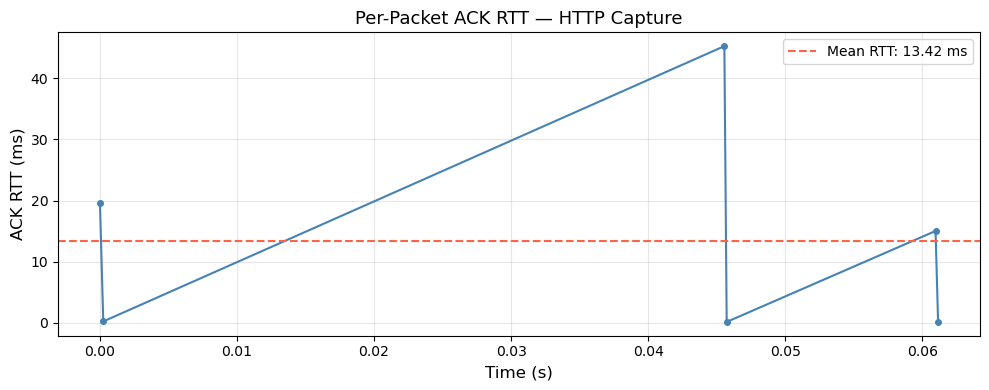

Packets with RTT data: 6
Mean RTT: 13.42 ms
Min RTT:  0.16 ms
Max RTT:  45.23 ms


In [16]:
import matplotlib.pyplot as plt

cap = pyshark.FileCapture(HTTP_PCAP, display_filter='tcp.analysis.ack_rtt')

rtts = []
times = []
start_time = None

for pkt in cap:
    try:
        rtt = float(pkt.tcp.analysis_ack_rtt) * 1000  # convert to ms
        t   = float(pkt.sniff_timestamp)
        if start_time is None:
            start_time = t
        rtts.append(rtt)
        times.append(t - start_time)
    except AttributeError:
        pass

cap.close()

if rtts:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(times, rtts, 'o-', color='steelblue', markersize=4, linewidth=1.5)
    ax.axhline(y=sum(rtts)/len(rtts), color='tomato', linestyle='--',
               label=f'Mean RTT: {sum(rtts)/len(rtts):.2f} ms')
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('ACK RTT (ms)', fontsize=12)
    ax.set_title('Per-Packet ACK RTT — HTTP Capture', fontsize=13)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('rtt_plot.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Packets with RTT data: {len(rtts)}")
    print(f"Mean RTT: {sum(rtts)/len(rtts):.2f} ms")
    print(f"Min RTT:  {min(rtts):.2f} ms")
    print(f"Max RTT:  {max(rtts):.2f} ms")
else:
    print("No RTT data found. Try a longer capture or a different site.")

## Step 6.6 — Protocol Distribution

0 TCP ['__bool__', '__class__', '__contains__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_packet_string', 'captured_length', 'eth', 'frame_info', 'get_multiple_layers', 'get_raw_packet', 'highest_layer', 'interface_captured', 'ipv6', 'layers', 'length', 'number', 'pretty_print', 'show', 'sniff_time', 'sniff_timestamp', 'tcp', 'transport_layer']
1 TCP ['__bool__', '__class__', '__contains__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__mod

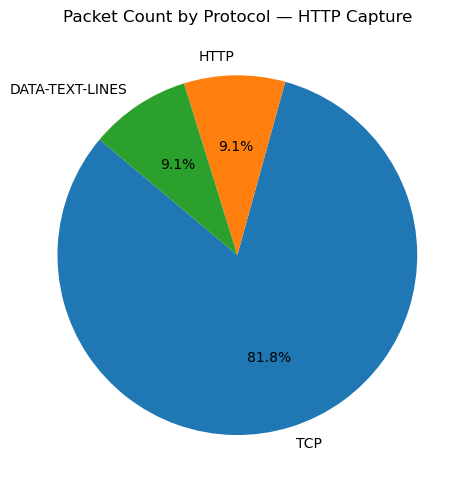

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

cap = pyshark.FileCapture(HTTP_PCAP)

proto_counts = Counter()
total_bytes  = Counter()

for pkt in cap:
    try:
        # Highest layer protocol
        proto = pkt.highest_layer
        length = int(pkt.length)
        proto_counts[proto] += 1
        total_bytes[proto]  += length
    except AttributeError:
        pass

cap.close()

# Display table
print(f"{'Protocol':<15} {'Packets':>10} {'Bytes':>12} {'% of traffic':>14}")
print("-" * 55)
total = sum(total_bytes.values())
for proto, count in proto_counts.most_common():
    b = total_bytes[proto]
    pct = b / total * 100 if total > 0 else 0
    print(f"{proto:<15} {count:>10} {b:>12,} {pct:>13.1f}%")

# Pie chart
fig, ax = plt.subplots(figsize=(7, 5))
protos = list(proto_counts.keys())
counts = [proto_counts[p] for p in protos]
ax.pie(counts, labels=protos, autopct='%1.1f%%', startangle=140)
ax.set_title('Packet Count by Protocol — HTTP Capture', fontsize=12)
plt.tight_layout()
plt.savefig('protocol_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6.7 — pyshark Analysis Questions

> (a) From the TCP handshake output (Step 6.4): identify the SYN, SYN-ACK, and ACK packets by row. What sequence numbers were chosen, and do they match what you'd expect from the three-way handshake lecture?  
> (b) Looking at your RTT plot (Step 6.5): is the RTT stable or does it vary? How does the mean RTT from pyshark compare to what `ping` reported to the same host?  
> (c) From the protocol distribution (Step 6.6): which protocol dominates by packet count?

a)

They appear to be the first three given the ACKs and sequence numbers. They are 0 and 1 and do seem like what is expected in the three way handshake.

b)

The RTT grows linearly before dropping like a sawtooth pattern. This seems about right for the RTT given by ping.

c)

TCP dominates the distribution by alot, at over 80% the total amount.


---

## Appendix: Command Reference

| Command | What it does |
|---------|-------------|
| `ping -c 10 <host>` | Send 10 ICMP echo requests, report RTT and loss |
| `traceroute -n <host>` | Trace path, skip DNS resolution |
| `ss -tin` | Show TCP sockets with internal info (cwnd, RTT) |
| `ss -tin \| grep -A1 ESTAB` | Filter for established connections only |
| `dig <host> <type>` | DNS query for record type A/AAAA/MX/NS/TXT |
| `dig @8.8.8.8 <host>` | Force query to specific DNS server |
| `sudo tcpdump -i <iface> -w out.pcap <filter>` | Capture to file with BPF filter |
| `tcpdump -r file.pcap -n -A` | Read pcap, numeric IPs, ASCII payload |
| `pyshark.FileCapture('file.pcap')` | Load pcap in Python |
| `pkt.highest_layer` | Get top-level protocol of a packet |
| `pkt.tcp.analysis_ack_rtt` | Per-packet ACK RTT (Wireshark computed field) |